# S7 — Why the analysis turns an updraft into a downdraft

**Question.** In the 1800 UTC GUES case there are cells where the truth has a *strong updraft*,
the prior has a *weak updraft*, and the analysis produces a *strong downdraft*. Is that physical,
an artefact of the DA setup, or an ensemble-size effect?

**Answer.** It is the linear update faithfully following a prior ensemble that has **no storm in
it**. Not an ensemble-size effect, not a code bug.

At the severe points the prior column is essentially clear air (mean reflectivity ~1.7 dBZ, only
~4 of 59 members carrying any echo) while the observation reports a ~42 dBZ core. The reflectivity
innovation is ~ +40 dBZ, the prior `cov(w, dBZ)` is **negative** — and it is a ~4-sample statistic,
95% of it contributed by the handful of echo-bearing members. Gain times innovation drives `w`
hard negative, *outside the prior ensemble's own range*. The truth lies outside that range too:
the ensemble simply cannot reach it.

**AOEI removes the pathology entirely** (24 → 0 severe points) because its inflated
`R̃ = max(R₀, d_b² − var(h)) ≈ 1525` shrinks the gain ~28×. **Tempering makes it worse**
(Nt=2 → 131, Nt=3 → 78), with the odd/even sawtooth already documented in
`test/diagnose_nt_parity.py`.

---

### Companion caveats about `SingleObs_CrossSection.ipynb`

* Its old reference column `i_c = 235` is **odd**, and the sweep runs at **stride 2** — that column
  was never assimilated. The storm max on `j=272, k=7` is at `i=236`.
* At `loc = 0.1 km` only the observed cell updates, so its Analysis panel is a **2-cell comb**.
* Its printed "16.8% sign-flip fraction" is **not** the pathology: 59% of those flips have
  `|w_f| < 0.05 m/s` and flip on rounding noise.

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt

REPO = '/nfsmounts/munin/datos/jorge.gacitua/WRF_Single_Cycle_Assimilation'
sys.path.insert(0, REPO + '/src/fortran')
from cletkf_wloc import common_da as cda

VI  = {'qg': 0, 'qr': 1, 'qs': 2, 'T': 3, 'P': 4, 'u': 5, 'v': 6, 'w': 7}
IW  = VI['w']
R0  = 5.0          # obs.obs_error_var
TM  = 0            # truth member
DBZ_MIN = 0.0

SWEEP  = REPO + '/data/WS_singleobs_xsec_1800_GUES/WS_singleobs_xsec_1800_GUES_sweep_Ne059_tm00.npz'
SUBSET = REPO + '/data/3D_subsets_20240319_GUES_20240319180000/subset_20240319180000.npz'
MO1800 = REPO + '/data/WS_multiobs_1800'

d = np.load(SWEEP, allow_pickle=True)
method, ntemp = d['method'].astype(str), d['ntemp']

def rows(meth, nt):
    """Rows of one combo, sorted by (i,j,k) so combos align point-for-point."""
    m = (method == meth) & (ntemp == nt)
    key = (d['i'][m].astype(np.int64) * 1000 + d['j'][m]) * 100 + d['k'][m]
    return m, np.argsort(key)

def col(name, m, o):
    return d[name][m][o].astype(np.float64)

COMBOS = {'LETKF (Nt=1)': ('TEnKF', 1), 'TEnKF Nt=2': ('TEnKF', 2),
          'TEnKF Nt=3': ('TEnKF', 3), 'AOEI': ('AOEI', 1)}
print({k: int((( method == v[0]) & (ntemp == v[1])).sum()) for k, v in COMBOS.items()})

{'LETKF (Nt=1)': 750931, 'TEnKF Nt=2': 750931, 'TEnKF Nt=3': 750931, 'AOEI': 750931}


## 1. The single-obs update has an exact closed form

For one scalar observation, `letkf_core` builds $P_a = [(N_e-1)I + hh^\top/R]^{-1}$ and
$\bar w_a = P_a h^\top d_b / R$. Applying Sherman–Morrison and contracting with the prior
perturbations collapses it exactly to the scalar Kalman update

$$\Delta w \;=\; \frac{\operatorname{cov}(w,h)}{\operatorname{var}(h)+R}\,d_b$$

with `cov`/`var` at `ddof=1`. Three facts make this **exact, not approximate**:

* `TEnKF, ntemp=1` **is** plain LETKF — `tempering_schedule(1, α) = [1.0]`, so `oerr = R₀`.
* At the observation's own cell the R-localisation weight is `exp(0) = 1`, so `rloc = oerr`.
* `w` is never clamped (only `qr/qs/qg` are), so its update is strictly linear.

Therefore `cov(w,h)` is **recoverable from data already on disk**, with no ensemble read:

$$\operatorname{cov}(w,h) \;=\; \Delta w \,\frac{\operatorname{var}(h)+R}{d_b}$$

### Validation with zero extra reads

Invert `cov(w,h)` off the LETKF rows, then use it to *predict* the AOEI rows, which inflate
`R̃ = max(R₀, d_b² − var(h))`. If the prediction reproduces the stored AOEI increments, the
whole framework is sound.

In [2]:
m_l, o_l = rows('TEnKF', 1)      # plain LETKF
m_a, o_a = rows('AOEI', 1)

dep   = col('dep_b', m_l, o_l)
var_h = col('spread_f_obs', m_l, o_l) ** 2
wf    = col('mean_f_point_w', m_l, o_l)
wa    = col('mean_a_point_w', m_l, o_l)
wt    = col('truth_point_w',  m_l, o_l)
hxf   = col('hxf_mean_obs',   m_l, o_l)
yo    = col('yo_clean',       m_l, o_l)
kk    = d['k'][m_l][o_l]

dep_a = col('dep_b', m_a, o_a)
wf_a  = col('mean_f_point_w', m_a, o_a)
wa_a  = col('mean_a_point_w', m_a, o_a)

# forecast columns must be combo-invariant (same prior, same observation)
assert np.nanmax(np.abs(dep - dep_a)) == 0 and np.nanmax(np.abs(wf - wf_a)) == 0

ok = np.abs(dep) > 1e-3
cov_wh = np.full(dep.shape, np.nan)
cov_wh[ok] = (wa - wf)[ok] * (var_h[ok] + R0) / dep[ok]      # <- the inversion
gain = cov_wh / (var_h + R0)

R_tilde = np.maximum(R0, dep_a ** 2 - var_h)                 # AOEI inflation
pred    = dep_a * cov_wh / (var_h + R_tilde)                 # predicted AOEI increment
truth_  = wa_a - wf_a                                        # stored AOEI increment

g = ok & np.isfinite(pred) & np.isfinite(truth_)
err = np.abs(pred[g] - truth_[g])
print(f'rows compared      : {g.sum()}')
print(f'max |abs error|    : {err.max():.3e} m/s')
print(f'median |abs error| : {np.median(err):.3e} m/s')
print(f'AOEI R-inflation active at {np.mean((dep_a**2 - var_h) > R0):.2%} of points')
print('\n-> float32 round-off. The scalar-gain identity is exact; cov(w,h) is trustworthy.')

rows compared      : 750440
max |abs error|    : 4.742e-06 m/s
median |abs error| : 0.000e+00 m/s
AOEI R-inflation active at 8.13% of points

-> float32 round-off. The scalar-gain identity is exact; cov(w,h) is trustworthy.


## 2. When does it fire?

Grade the pathology by magnitude. The bare sign-flip fraction is dominated by cells whose prior
`w` sits at the noise floor.

In [3]:
soft = (np.sign(wa) != np.sign(wf)) & (np.abs(wf) > 1e-6)
print(f'bare sign-flip fraction     : {np.nanmean(soft):.3%}')
print(f'  ... with |w_f| < 0.05 m/s : {np.nanmean(np.abs(wf[soft]) < 0.05):.1%}  <- noise, not signal\n')

print('truth updraft & prior updraft & analysis downdraft:')
for thr in (0.25, 0.5, 1.0, 2.0):
    s = (wt > thr) & (wf > 0) & (wa < -thr)
    print(f'  |w| > {thr:<4}  {int(s.sum()):>5d} points  ({s.mean():.4%})')

BAD = (wt > 1.0) & (wf > 0) & (wa < -1.0)
print(f'\nat the {int(BAD.sum())} severe points        (vs all QC points)')
print(f'  cov(w,h) < 0 : {np.nanmean(cov_wh[BAD] < 0):>6.1%}   ({np.nanmean(cov_wh[ok] < 0):.1%})')
print(f'  dep_b    > 0 : {np.nanmean(dep[BAD] > 0):>6.1%}   ({np.nanmean(dep[ok] > 0):.1%})')
for lbl, arr in (('prior dBZ', hxf), ('obs dBZ', yo), ('innovation d_b', dep),
                 ('cov(w,h)', cov_wh), ('gain K', gain),
                 ('w_f', wf), ('w_a', wa), ('w_truth', wt)):
    print(f'  {lbl:14s}: {np.nanmedian(arr[BAD]):>9.3f}   ({np.nanmedian(arr[ok]):>9.3f})')

print(f"\ncheck: K * d_b = {np.nanmedian(gain[BAD]) * np.nanmedian(dep[BAD]):.3f} m/s"
      f"   vs stored median increment {np.nanmedian((wa - wf)[BAD]):.3f} m/s")

bare sign-flip fraction     : 16.795%
  ... with |w_f| < 0.05 m/s : 58.7%  <- noise, not signal

truth updraft & prior updraft & analysis downdraft:
  |w| > 0.25    886 points  (0.1180%)
  |w| > 0.5     124 points  (0.0165%)
  |w| > 1.0      24 points  (0.0032%)
  |w| > 2.0       1 points  (0.0001%)

at the 24 severe points        (vs all QC points)
  cov(w,h) < 0 : 100.0%   (47.6%)
  dep_b    > 0 : 100.0%   (30.6%)
  prior dBZ     :     1.693   (    1.518)
  obs dBZ       :    41.885   (    0.000)
  innovation d_b:    39.725   (   -0.589)
  cov(w,h)      :    -2.000   (    0.006)
  gain K        :    -0.036   (    0.001)
  w_f           :     0.038   (    0.010)
  w_a           :    -1.214   (    0.004)
  w_truth       :     3.235   (   -0.003)

check: K * d_b = -1.418 m/s   vs stored median increment -1.278 m/s


## 3. Is that covariance trustworthy? Go to the ensemble

`cov(w,h)` being negative is only meaningful if the ensemble carries information. Reflectivity is
clamped at `dbz_min = 0`, so in a clear-air column most members sit at exactly 0 dBZ and contribute
nothing. QC only demands `var(h) > 0`, i.e. **two distinct values suffice**.

Read the prior ensemble at the severe points plus a control sample, and ask:

1. does the directly-computed `cov(w,h)` match the inverted one? (closes the loop)
2. how many members actually carry echo?
3. is the analysis mean `w` **outside** the prior members' `[min, max]`? (LETKF weights may be negative)
4. does the prior ensemble even **bracket** the truth's `w`?

In [4]:
rng  = np.random.default_rng(7)
ctrl = rng.choice(np.flatnonzero(~BAD), 30000, replace=False)
sel  = np.concatenate([np.flatnonzero(BAD), ctrl])
is_bad = np.zeros(sel.size, bool); is_bad[:int(BAD.sum())] = True

ii, jj, kk_s = d['i'][m_l][o_l][sel], d['j'][m_l][o_l][sel], kk[sel]
with np.load(SUBSET) as z:                       # ~10.6 GB, transient
    sub = z['state_ensemble'][ii, jj, kk_s, :, :].copy()

members = [x for x in range(sub.shape[1]) if x != TM]
NE = len(members)
xf_e, truth_e = sub[:, members, :], sub[:, TM, :]

def hx(state):                                   # (npts, nbv, 8) -> (npts, nbv)
    s = state[:, None, None, :, :]
    ref = cda.calc_ref_ens(s[..., VI['qr']].astype(np.float64), s[..., VI['qs']].astype(np.float64),
                           s[..., VI['qg']].astype(np.float64), s[..., VI['T']].astype(np.float64),
                           s[..., VI['P']].astype(np.float64), min_dbz=DBZ_MIN)
    return np.maximum(np.asarray(ref)[:, 0, 0, :], DBZ_MIN).astype(np.float32)

h  = hx(xf_e); h64 = h.astype(np.float64)
w  = xf_e[:, :, IW].astype(np.float64)

print(f'reconstruction vs pipeline: max |spread_f_obs diff| = '
      f'{np.nanmax(np.abs(h64.std(1, ddof=1) - col("spread_f_obs", m_l, o_l)[sel])):.2e} dBZ')

cov_direct = ((w - w.mean(1, keepdims=True)) * (h64 - h64.mean(1, keepdims=True))).sum(1) / (NE - 1)
gd = np.isfinite(cov_direct) & np.isfinite(cov_wh[sel])
print(f'cov(w,h) direct vs inverted: corr = {np.corrcoef(cov_direct[gd], cov_wh[sel][gd])[0,1]:.9f}, '
      f'median |diff| = {np.nanmedian(np.abs(cov_direct - cov_wh[sel])[gd]):.2e}\n')

n_active = (h > DBZ_MIN).sum(1)
wmin, wmax = w.min(1), w.max(1)
outside  = (wa[sel] < wmin - 1e-6) | (wa[sel] > wmax + 1e-6)
tr_out   = (wt[sel] < wmin) | (wt[sel] > wmax)

print(f'{"":9s} {"n_active (of "+str(NE)+")":>20s} {"w_a outside hull":>18s} {"truth outside hull":>20s}')
for lbl, msk in (('severe', is_bad), ('control', ~is_bad)):
    print(f'{lbl:9s} {np.median(n_active[msk]):>20.1f} {np.nanmean(outside[msk]):>18.2%} '
          f'{np.nanmean(tr_out[msk]):>20.2%}')

frac = []
for t in np.flatnonzero(is_bad):
    c = (w[t] - w[t].mean()) * (h64[t] - h64[t].mean()) / (NE - 1)
    if c.sum() != 0:
        frac.append(c[h[t] > DBZ_MIN].sum() / c.sum())
print(f'\nfraction of cov(w,h) carried by the echo-bearing members: median {np.median(frac):.3f}')
print(f'-> the covariance is effectively a {np.median(n_active[is_bad]):.0f}-sample estimate')

reconstruction vs pipeline: max |spread_f_obs diff| = 2.74e-06 dBZ
cov(w,h) direct vs inverted: corr = 1.000000000, median |diff| = 3.80e-07

              n_active (of 59)   w_a outside hull   truth outside hull
severe                     4.5             16.67%               83.33%
control                    5.0              0.02%                2.67%

fraction of cov(w,h) carried by the echo-bearing members: median 0.954
-> the covariance is effectively a 4-sample estimate


In [5]:
print(f'{"k":>2s} {"n_act":>5s} {"w_min":>7s} {"w_max":>7s} {"w_f":>7s} {"w_a":>8s} '
      f'{"w_true":>8s} {"cov":>8s} {"d_b":>7s} {"hxf":>6s} {"yo":>6s}')
for t in np.flatnonzero(is_bad)[:12]:
    print(f'{kk_s[t]:>2d} {n_active[t]:>5d} {wmin[t]:>7.2f} {wmax[t]:>7.2f} {wf[sel][t]:>7.2f} '
          f'{wa[sel][t]:>8.2f} {wt[sel][t]:>8.2f} {cov_direct[t]:>8.2f} {dep[sel][t]:>7.2f} '
          f'{hxf[sel][t]:>6.2f} {yo[sel][t]:>6.2f}')
print('\nRead the k=9 row: the prior spans w in [-0.73, 0.88] with ONE echo member, the truth has')
print('+15.4 m/s and 50 dBZ. No linear combination of that ensemble reaches the truth; the single')
print('echo member has negative w, so a +49.5 dBZ innovation drives w_a to -1.08, outside the hull.')

 k n_act   w_min   w_max     w_f      w_a   w_true      cov     d_b    hxf     yo
 7     2   -1.20    0.70    0.03    -1.10     3.90    -0.62   38.42   0.61  38.25
 2     4   -1.72    1.79    0.07    -1.13     1.44    -2.79   28.01   1.85  30.70
 9     1   -0.73    0.88    0.02    -1.08    15.39    -0.22   49.51   0.29  50.52
 8     2   -1.52    0.88    0.05    -1.08     1.08    -0.22   43.60   0.35  43.51
 5     3   -2.37    1.36    0.00    -1.21     5.11    -1.77   42.07   1.57  46.01
 5     6   -1.45    1.00    0.05    -1.22     4.41    -1.18   38.29   1.54  39.90
 5     3   -3.90    2.36    0.04    -2.85     5.58    -1.95   37.18   0.98  39.37
 4     7   -1.78    1.58    0.03    -1.46     2.04    -1.30   42.83   1.50  47.03
 5     4   -2.21    2.26    0.06    -1.36     4.05    -2.53   39.72   1.84  41.77
 4     3   -1.99    0.54    0.00    -2.51     1.55    -0.72   45.35   0.48  43.48
 2     5   -2.05    2.06    0.05    -1.12     1.33    -1.17   30.16   1.28  33.77
 2     6   -2.43

## 4. Does the method matter? AOEI cures it; tempering aggravates it

Same points, same prior, same observations — only the update rule changes. `BAD` is fixed to the
LETKF severe set so the columns are comparable point-for-point.

combo           severe   med |dw| on BAD   med w_a on BAD   max |dw|
LETKF (Nt=1)        24             1.278           -1.214      26.12
TEnKF Nt=2         131             1.036           -0.988      17.61
TEnKF Nt=3          78             0.884           -0.847      11.58
AOEI                 0             0.058           -0.004       5.56

AOEI at the severe points: median R_tilde = 1487 vs R0 = 5.0  -> gain shrinks 26x


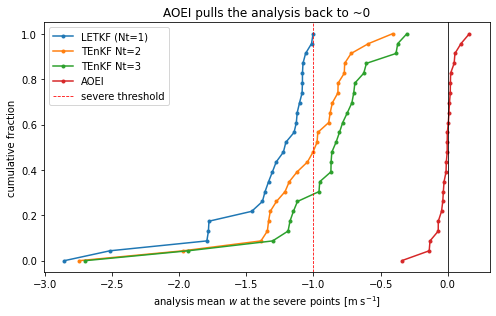

In [6]:
print(f'{"combo":14s} {"severe":>7s} {"med |dw| on BAD":>17s} {"med w_a on BAD":>16s} {"max |dw|":>10s}')
res = {}
for name, (mm, nt) in COMBOS.items():
    mk, ok_ = rows(mm, nt)
    a, f_, t_ = col('mean_a_point_w', mk, ok_), col('mean_f_point_w', mk, ok_), col('truth_point_w', mk, ok_)
    sev = int(((t_ > 1.0) & (f_ > 0) & (a < -1.0)).sum())
    res[name] = a
    print(f'{name:14s} {sev:>7d} {np.nanmedian(np.abs(a - f_)[BAD]):>17.3f} '
          f'{np.nanmedian(a[BAD]):>16.3f} {np.nanmax(np.abs(a - f_)):>10.2f}')

Rt = np.maximum(R0, dep[BAD] ** 2 - var_h[BAD])
print(f'\nAOEI at the severe points: median R_tilde = {np.median(Rt):.0f} vs R0 = {R0}'
      f'  -> gain shrinks {np.median((var_h[BAD] + Rt) / (var_h[BAD] + R0)):.0f}x')

fig, ax = plt.subplots(figsize=(7, 4.5))
for name in COMBOS:
    ax.plot(np.sort(res[name][BAD]), np.linspace(0, 1, int(BAD.sum())), marker='.', label=name)
ax.axvline(0, c='k', lw=.8); ax.axvline(-1, c='r', ls='--', lw=.8, label='severe threshold')
ax.set_xlabel('analysis mean $w$ at the severe points [m s$^{-1}$]')
ax.set_ylabel('cumulative fraction'); ax.legend(); ax.set_title('AOEI pulls the analysis back to ~0')
fig.tight_layout(); plt.show()

## 5. The multi-obs side, and the localisation x ensemble-size matrix

`data/WS_multiobs_1800/` is `loc = 2.0 km`, `Ne = 40`, stride 2. Each cell there sees ~343 local
observations rather than one, so the scalar identity no longer applies — but the signed increment
is still exactly `bias_a_field - bias_f_field` (the truth cancels, so no float32 reconstruction
error; never rebuild the mean as `truth + bias`).

The diagnostic matrix separates localisation from ensemble size. `sweep.obs_mask_from` pins every
run to `ref_Ne040`'s 693,783 observations, so the cells differ **only** in the axis being tested.
Runs still in flight are reported as `pending`.

In [7]:
D = REPO + '/data'

# The observation set shared by every run (`sweep.obs_mask_from` pins R2/R6 to it).
with np.load(f'{MO1800}/WS_multiobs_1800_multi_obs_ref_Ne040_tm00.npz') as r:
    ix, iy, iz = r['ix'].copy(), r['iy'].copy(), r['iz'].copy()
mask = np.zeros((558, 898, 11), bool); mask[ix, iy, iz] = True
assert len(ix) == 693783, 'unexpected mask size -- did a stale ref get adopted?'

# Each run has its OWN prior mean: xf_mean depends on Ne. Reading xf_mean from ref_Ne040 for an
# Ne=59 run would silently compare against the wrong prior, so always take it from the run's own
# reference file. `truth` IS shared (it is member tm=0, independent of Ne) -- asserted below.
RUNS = {
    ('loc=0.1', 'Ne=40'): (f'{D}/WS_diag1800_MO_L0.1_Ne40', 'WS_diag1800_MO_L0.1_Ne40', 'Lx0.1Ly0.1Lz0.1', 'Ne040'),
    ('loc=0.1', 'Ne=59'): (f'{D}/WS_diag1800_MO_L0.1_Ne59', 'WS_diag1800_MO_L0.1_Ne59', 'Lx0.1Ly0.1Lz0.1', 'Ne059'),
    ('loc=2.0', 'Ne=40'): (f'{MO1800}',                     'WS_multiobs_1800',         'Lx2.0Ly2.0Lz2.0', 'Ne040'),
    ('loc=2.0', 'Ne=59'): (f'{D}/WS_diag1800_MO_L2.0_Ne59', 'WS_diag1800_MO_L2.0_Ne59', 'Lx2.0Ly2.0Lz2.0', 'Ne059'),
}

def severe_multiobs(key, fn='TEnKF_Nt01'):
    dirp, tag, lstr, nestr = RUNS[key]
    p  = f'{dirp}/{tag}_multi_obs_{fn}_as1.0_{lstr}_{nestr}_tm00.npz'
    rp = f'{dirp}/{tag}_multi_obs_ref_{nestr}_tm00.npz'
    if not (os.path.exists(p) and os.path.exists(rp)):
        return None
    with np.load(rp) as r:
        assert np.array_equal(r['ix'], ix), f'{tag}: obs mask differs'
        w_f = r['xf_mean'][..., IW].astype(np.float64)     # this run's own prior
        w_t = r['truth'][..., IW].astype(np.float64)
    with np.load(p) as f:                                  # truth cancels in the increment
        dw = (f['bias_a_field'][..., IW] - f['bias_f_field'][..., IW]).astype(np.float64)
    a, fp, t = (w_f + dw)[ix, iy, iz], w_f[ix, iy, iz], w_t[ix, iy, iz]
    return int(np.nansum((t > 1.0) & (fp > 0) & (a < -1.0)))

def severe_sweep(path, meth='TEnKF', nt=1):
    if not os.path.exists(path):
        return None
    with np.load(path, allow_pickle=True) as s:
        mk = (s['method'].astype(str) == meth) & (s['ntemp'] == nt)
        i_, j_, k_ = s['i'][mk], s['j'][mk], s['k'][mk]
        keep = mask[i_, j_, k_]                            # restrict to the common obs set
        a  = s['mean_a_point_w'][mk][keep]
        fp = s['mean_f_point_w'][mk][keep]
        t  = s['truth_point_w'][mk][keep]
    return int(np.nansum((t > 1.0) & (fp > 0) & (a < -1.0)))

print(f'severe points (LETKF Nt=1) on the common {len(ix):,}-point observation set\n')
print(f'{"":10s} {"Ne=40":>10s} {"Ne=59":>10s}')
grid = {}
for loc in ('loc=0.1', 'loc=2.0'):
    row = []
    for ne in ('Ne=40', 'Ne=59'):
        n = severe_multiobs((loc, ne))
        grid[(loc, ne)] = n
        row.append('pending' if n is None else str(n))
    print(f'{loc:10s} {row[0]:>10s} {row[1]:>10s}')

print('\nsingle-obs sweeps, same observation set:')
s59 = severe_sweep(SWEEP)
s40 = severe_sweep(f'{D}/WS_diag1800_SW_L0.1_Ne40/WS_diag1800_SW_L0.1_Ne40_sweep_Ne040_tm00.npz')
print(f'  sweep Ne=59 : {s59}\n  sweep Ne=40 : {s40}')
if grid[('loc=0.1', 'Ne=40')] is not None:
    print(f"  -> sweep Ne=40 ({s40}) must equal multiobs loc=0.1 Ne=40 "
          f"({grid[('loc=0.1','Ne=40')]}): {s40 == grid[('loc=0.1','Ne=40')]}")

print('\nreading the matrix:')
print('  along a row   (Ne=40 -> Ne=59) : ensemble-size effect')
print('  down a column (0.1 -> 2.0 km)  : joint assimilation + localisation')
print('  sweep vs multiobs at loc=0.1   : must agree (verified; zero rows over physical tolerance)')
if all(v is not None for v in grid.values()):
    dl = grid[('loc=2.0', 'Ne=40')] / max(grid[('loc=0.1', 'Ne=40')], 1)
    dn = grid[('loc=2.0', 'Ne=59')] / max(grid[('loc=2.0', 'Ne=40')], 1)
    print(f'\n  localisation 0.1 -> 2.0 km at Ne=40 : x{dl:.1f}')
    print(f'  ensemble 40 -> 59 at loc=2.0        : x{dn:.2f}')

severe points (LETKF Nt=1) on the common 693,783-point observation set

                Ne=40      Ne=59
loc=0.1            18         22
loc=2.0           125        198

single-obs sweeps, same observation set:
  sweep Ne=59 : 22
  sweep Ne=40 : 18
  -> sweep Ne=40 (18) must equal multiobs loc=0.1 Ne=40 (18): True

reading the matrix:
  along a row   (Ne=40 -> Ne=59) : ensemble-size effect
  down a column (0.1 -> 2.0 km)  : joint assimilation + localisation
  sweep vs multiobs at loc=0.1   : must agree (verified; zero rows over physical tolerance)

  localisation 0.1 -> 2.0 km at Ne=40 : x6.9
  ensemble 40 -> 59 at loc=2.0        : x1.58
